**Seasonal Agriculture Performance Analysis**


**Major Data Analytics Project**

**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, Numpy, Matplotlib, Seaborn


**Project Goal**

Investigate how Agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

**1. Problem Statement**

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

**2. Project Objectives**

1. Explore and understand the dataset.

2. Clean and prepare the data for analysis.

3. Examine how agricultural performance varies across seasons.

4. Identify important seasonal patterns and trends.

5. Investigate relationships between seasonal conditions and agricultural outcomes.

6. Compare relevant groups within different seasons.

7. Identify significant differences or unusual patterns.

8. Apply appropriate statistical and visualization techniques.

9. Interpret findings based on evidence from the dataset.

10. Develop meaningful conclusions and data-driven recommendations.

**3. Dataset**

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environment conditions, farming practices, production, costs, revenue, profit and resource usage.

In [4]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format",lambda x:f"{x:,.2f}")

In [6]:
# Load the dataset

file_path="/content/seasonal_agriculture_performance_dataset.csv"
df=pd.read_csv(file_path)

print("Dataset loaded successfully")

Dataset loaded successfully


**4. Initial Data Understanding**

In [8]:
# Dataset shape

print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 4000
Number of columns: 28


In [9]:
# Top 5 rows

df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [11]:
# Bottom 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [12]:
# Random sample of records

df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [13]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [14]:
# Data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [15]:
# Numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [16]:
# Categorical summary

df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**5. Data Quality Analysis**

In [19]:
# Missing values

missing=df.isnull().sum().sort_values(ascending=False)
missing_percentage=(df.isnull().mean()*100).sort_values(ascending=False)
missing_summary=pd.DataFrame({
    "Missing Count":missing,
    "Missing Percentage":missing_percentage.round(2)
})
missing_summary[missing_summary["Missing Count"]>0]

,Missing Count,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


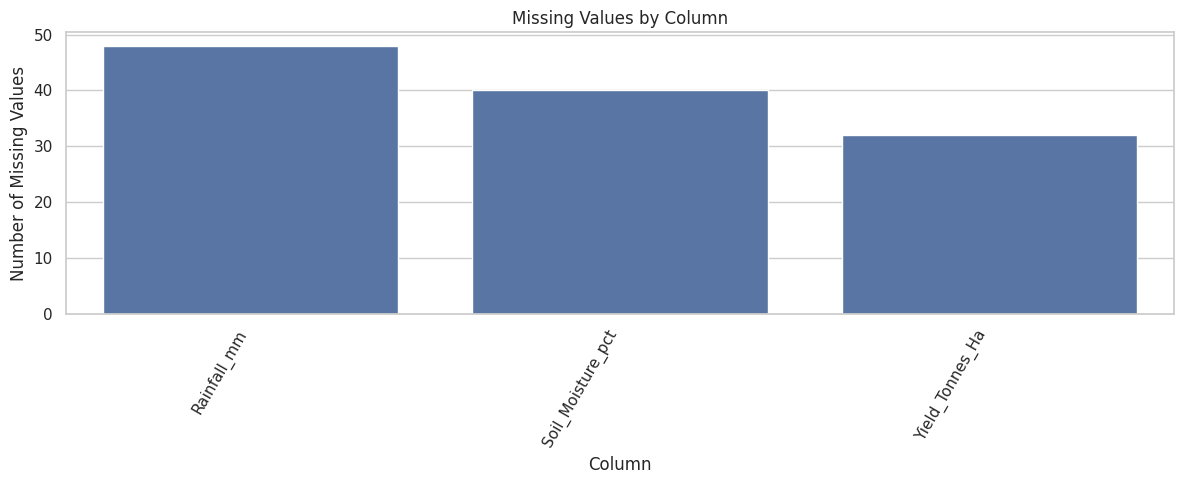

In [20]:
# Visualize missing values

plt.figure(figsize=(12,5))
missing_plot=missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index,y=missing_plot.values)
  plt.xticks(rotation=60,ha="right")
  plt.ylabel("Number of Missing Values")
  plt.xlabel("Column")
  plt.title("Missing Values by Column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found")

In [21]:
# Duplicate records

duplicate_count=df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


In [22]:
# Remove duplicate rows

df=df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [23]:
# Check data types again

df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [24]:
# Check unique values for categorical columns

categorical_columns=df.select_dtypes(include="object").columns
for col in categorical_columns:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [25]:
# Check missing values after duplicate removal

df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Possible approaches:
*   Remove records only when justified.
*   Fill numerical values using an appropriate statistic when appropriate.
*   Fill categorical values using a suitable category or method.
*   Clearly document why the chosen approach is reasonable.

In [26]:
numeric_columns=df.select_dtypes(include=np.number).columns
for col in numeric_columns:
  if df[col].isnull().sum()>0:
    df[col]=df[col].fillna(df[col].median())
print("Remaining missing values:",df.isnull().sum().sum())

Remaining missing values: 0


**6. Feature/Variable Review**



*   Identifier variables
*   Categorical variables
*   Numerical variables
*   Environmental variables
*   Operational variables
*   Production/performance variables
*   Economic variables










In [27]:
# Numerical and categorical columns

numeric_columns=df.select_dtypes(include=np.number).columns.tolist()
categorical_columns=df.select_dtypes(include="object").columns.tolist()
print("Numerical columns:",numeric_columns)
print("Categorical columns:",categorical_columns)

Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


**7. Statistical Analysis**

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [29]:
# Descriptive statistics

stats=df[numeric_columns].describe().T
stats["range"]=stats["max"]-stats["min"]
stats["IQR"]=stats["75%"]/stats["25%"]
stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,2.73
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",2.24
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,1.24
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,1.31
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.23
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,1.14
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,1.43
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,1.43
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,1.50
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,1.43


In [31]:
# Median and Standard deviation

statistical_summary=pd.DataFrame({
    "Mean":df[numeric_columns].mean(),
    "Median":df[numeric_columns].median(),
    "Standard Deviation":df[numeric_columns].std(),
    "Min":df[numeric_columns].min(),
    "Max":df[numeric_columns].max()
})
statistical_summary

,Mean,Median,Standard Deviation,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [33]:
# Seasonal descriptive summary

season_summary=df.groupby("Season")[numeric_columns].agg({"mean","median","std"})
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                      std median mean         std median   mean   
Season                                                            
Kharif               4.28   8.18 7.94      183.69 853.10 849.20   
Rabi                 4.18   7.68 7.75      175.35 432.20 437.62   
Zaid                 4.16   8.09 8.09      157.24 288.20 304.65   

       Avg_Temperature_C              Humidity_pct               \
                     std median  mean          std median  mean   
Season                                                            
Kharif              2.51  28.50 28.45         8.86  71.90 71.81   
Rabi                2.46  23.50 23.49         9.00  58.10 57.89   
Zaid                2.55  31.00 31.04         9.05  52.35 52.01   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                      std median mean     std median mean               std   
Season                                                                        
Kharif               0.98   6.80 6.79    0.64   6.73 6.73              5.04   
Rabi                 1.00   7.60 7.59    0.64   6.67 6.67              4.94   
Zaid                 1.05   8.20 8.18    0.64   6.66 6.69              4.94   

                    Nitrogen_kg_ha               Phosphorus_kg_ha         \
       median  mean            std median   mean              std median   
Season                                                                     
Kharif  31.10 31.15          31.18 119.80 120.02            17.15  57.40   
Rabi    24.00 24.07          31.10 120.30 120.40            17.12  57.70   
Zaid    19.10 19.28          31.70 120.15 120.53            16.29  57.45   

             Potassium_kg_ha               Fertilizer_kg_ha                \
        mean             std median   mean              std median   mean   
Season                                                                      
Kharif 58.10           27.03 104.80 105.30            60.82 188.20 187.08   
Rabi   57.31           28.87 104.80 103.93            59.95 185.30 185.41   
Zaid   58.13           26.66 106.30 105.42            59.47 183.95 184.64   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                      std median mean                std median mean   
Season                                                                 
Kharif               1.96   5.18 5.08               0.10   0.82 0.82   
Rabi                 1.99   5.02 5.02               0.10   0.84 0.83   
Zaid                 1.99   5.19 5.17               0.10   0.83 0.82   

       Yield_Tonnes_Ha             Production_Tonnes               \
                   std median mean               std median  mean   
Season                                                              
Kharif           14.39   1.94 5.63            135.70  13.24 46.31   
Rabi             12.75   1.67 5.04            121.90  11.08 41.49   
Zaid             11.27   1.46 4.64            112.00   9.97 38.89   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                          std    median      mean            std     median   
Season                                                                        
Kharif              30,301.56 25,793.00 44,850.91     298,487.69 524,840.00   
Rabi                30,309.56 26,041.00 44,747.97     288,386.89 506,733.00   
Zaid                30,086.23 25,749.50 44,212.03     297,576.86 534,833.00   

                  Revenue_INR                       Profit_INR             \
             mean         std     median       mean        std     median   
Season                                                                      
Kharif 531,804.41  708,710.37 520,196.00 710,719.06 611,549.78  38,808.00   
Rabi   513,836.58  584,545.52 438,156.00 601,526.05 489,901.25  -3,187.00   
Zaid   543,976.73  509,524.55 373,700.50 519,171.90 436,356.75 -62,144.00   

                  Wa

**8. Univariate Analysis**

Univariate analysis examines one variable at a time.

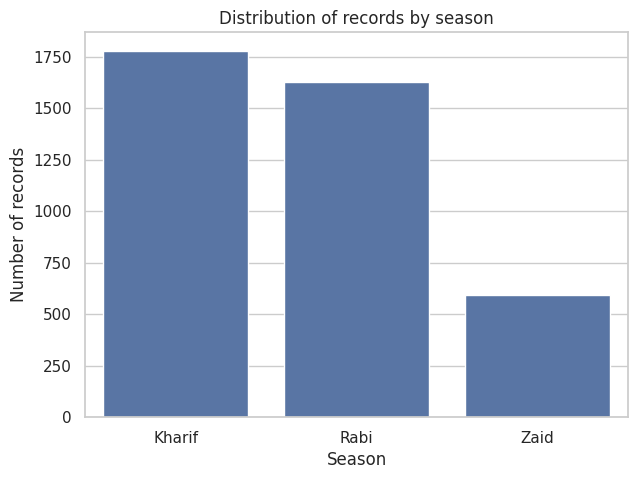

In [34]:
# Univariate: Season distribution

plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("Distribution of records by season")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout
plt.show()

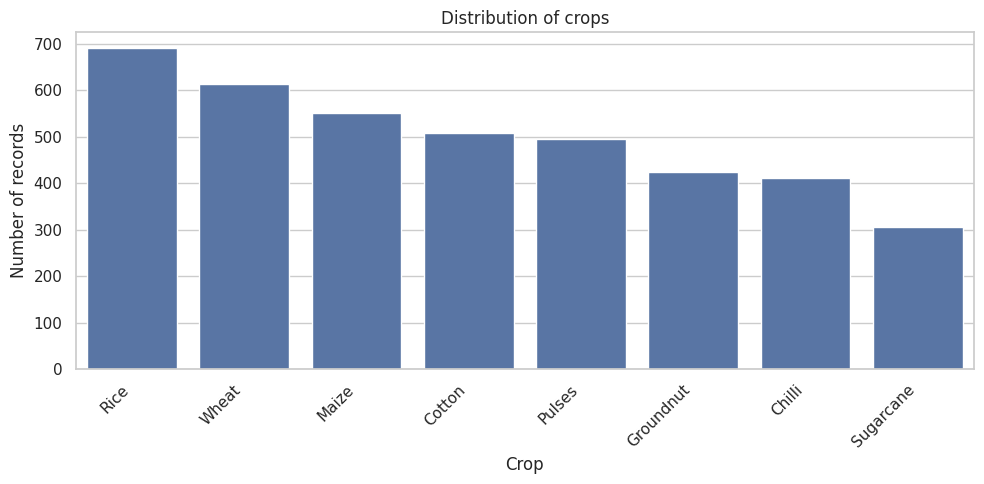

In [36]:
# Univariate: crop distribution

plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.xticks(rotation=45,ha="right")
plt.title("Distribution of crops")
plt.xlabel("Crop")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

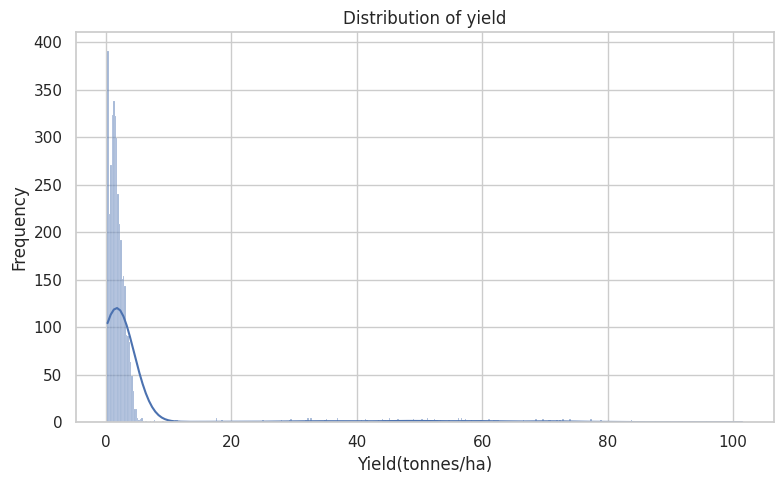

In [38]:
# Univariate: yield distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distribution of yield")
plt.xlabel("Yield(tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

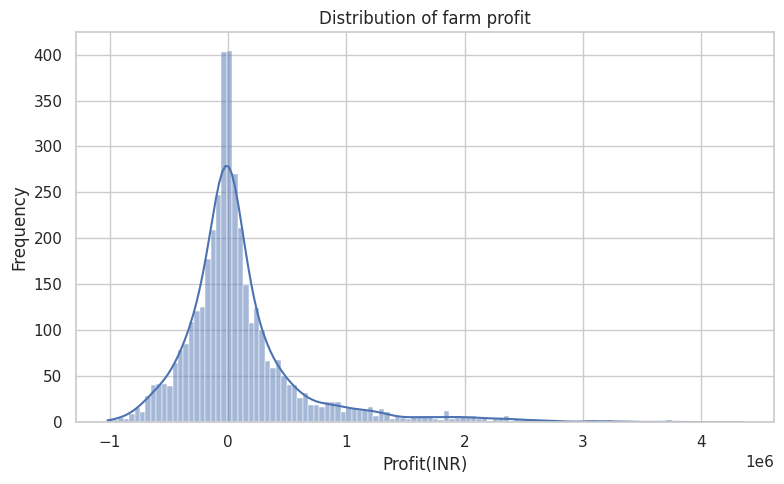

In [39]:
# Univariate: Profit distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR",kde=True)
plt.title("Distribution of farm profit")
plt.xlabel("Profit(INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

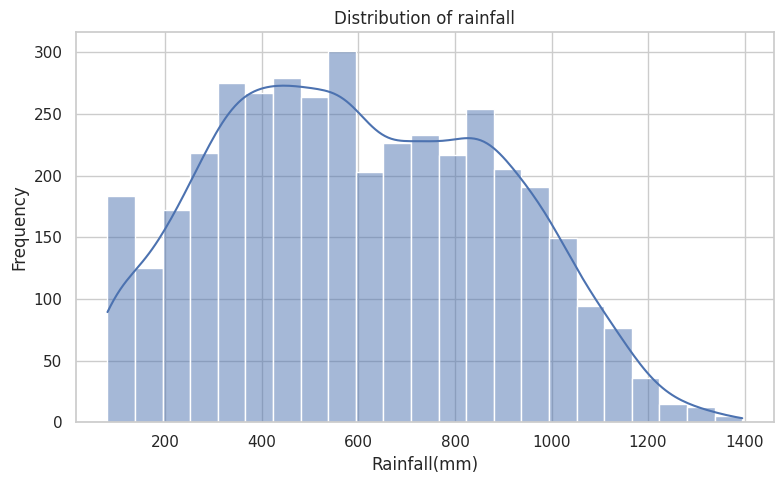

In [40]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of rainfall")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


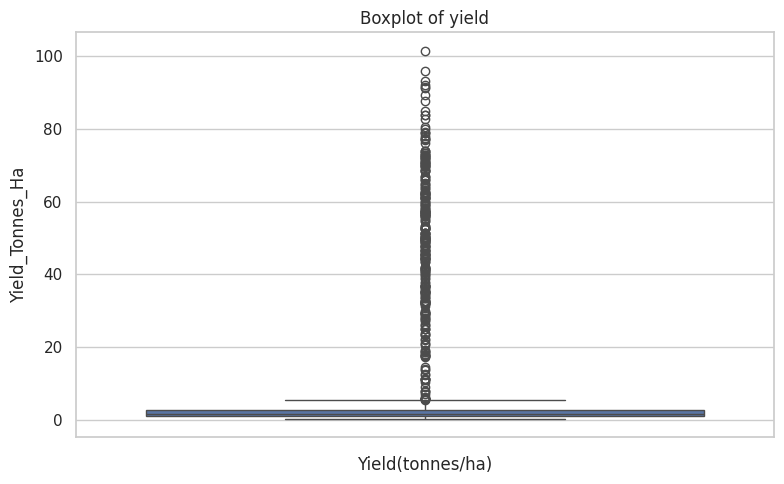

In [42]:
# Univariate: Boxplot for yield

plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Boxplot of yield")
plt.xlabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

**9. Outlier Analysis**



Univariate: Season distribution(Pie chart)

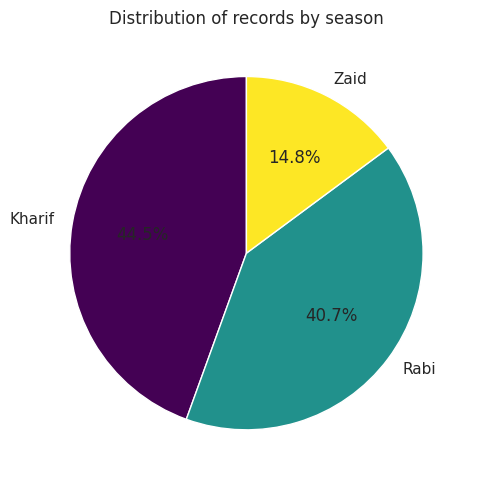

In [44]:
plt.figure(figsize=(5,5))
df['Season'].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap='viridis')
plt.title('Distribution of records by season')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [45]:
# IQR based outlier summary for numerical columns

outlier_summary=[]
for col in numeric_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  count=((df[col]<lower_bound)|(df[col]>upper_bound)).sum()
  outlier_summary.append({
      "Column":col,
      "Lower Bound":lower_bound,
      "Upper Bound":upper_bound,
      "Outlier_count":count,
      "Outlier_percentage":round(count/len(df)*100,2)
  })
outlier_summary=pd.DataFrame(outlier_summary).sort_values("Outlier_count",ascending=False)
outlier_summary

,Column,Lower Bound,Upper Bound,Outlier_count,Outlier_percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


**10. Bivariate Analysis**

<function matplotlib.pyplot.show(close=None, block=None)>

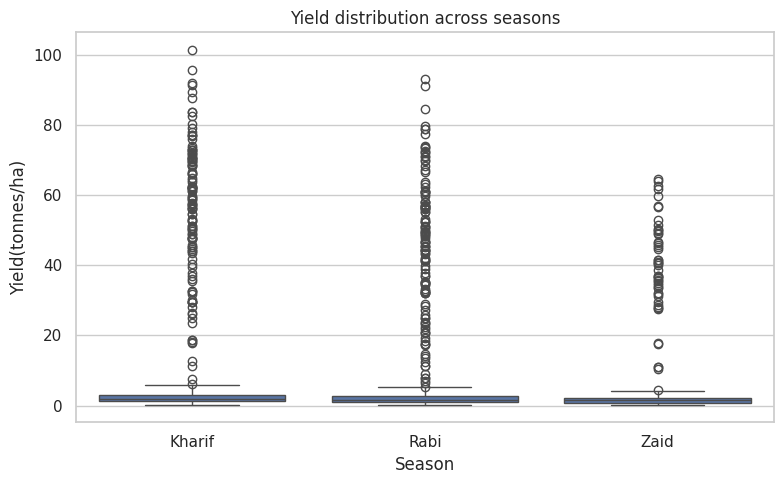

In [47]:
# Bivariate: season vs yield

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("Yield distribution across seasons")
plt.xlabel("Season")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show

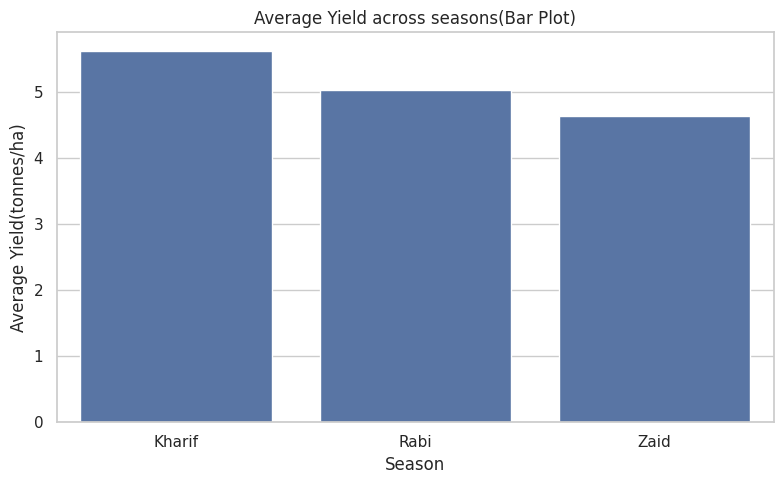

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average Yield across seasons(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

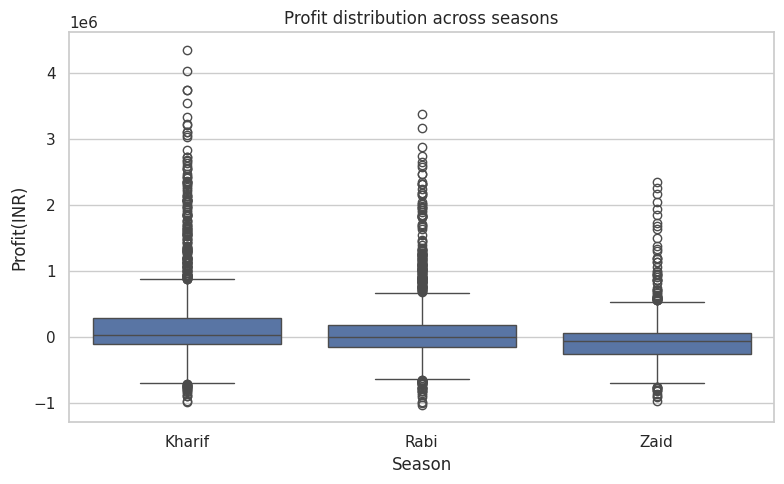

In [48]:
# Bivariate: season vs profit

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("Profit distribution across seasons")
plt.xlabel("Season")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

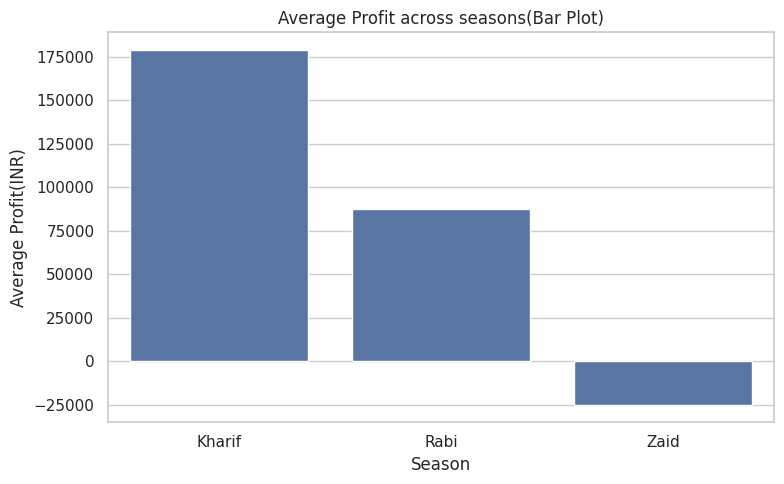

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("Average Profit across seasons(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit(INR)")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

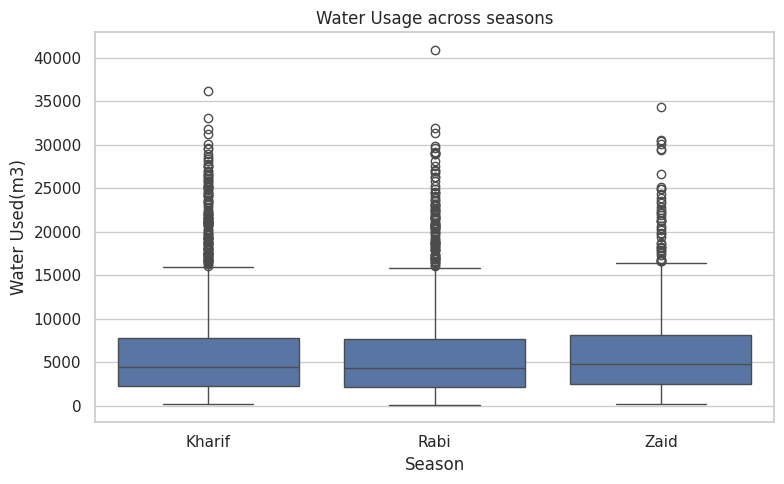

In [51]:
# Bivariate: Season vs Water usage
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("Water Usage across seasons")
plt.xlabel("Season")
plt.ylabel("Water Used(m3)")
plt.tight_layout()
plt.show

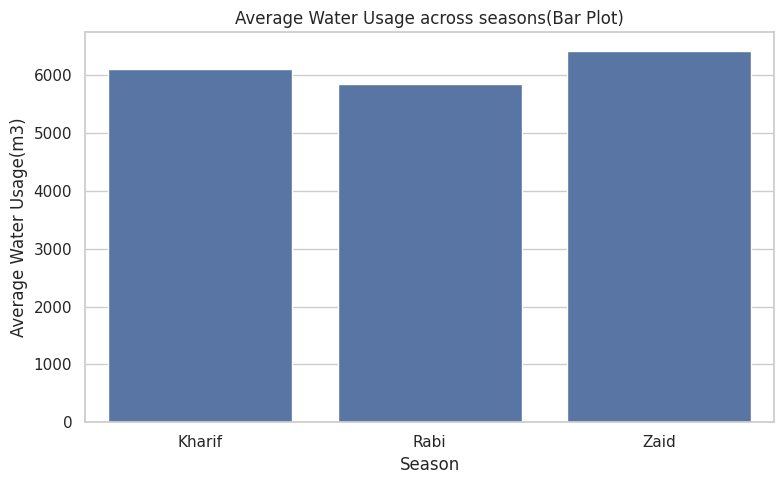

In [52]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Average Water Usage across seasons(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Water Usage(m3)")
plt.tight_layout()
plt.show()

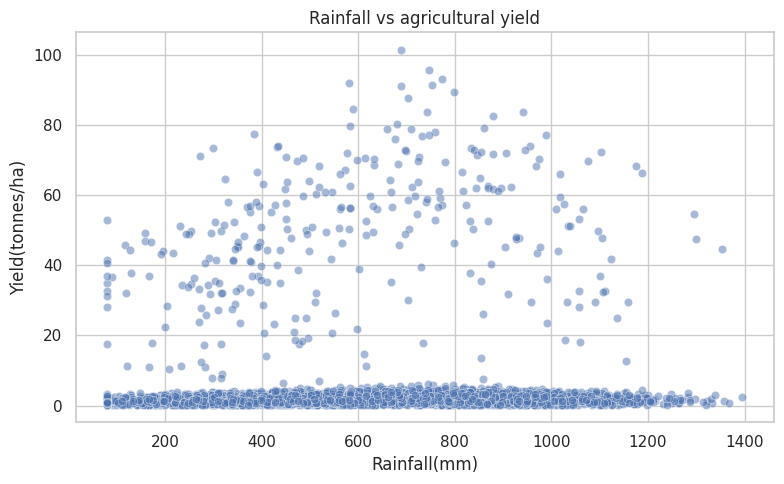

In [53]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("Rainfall vs agricultural yield")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

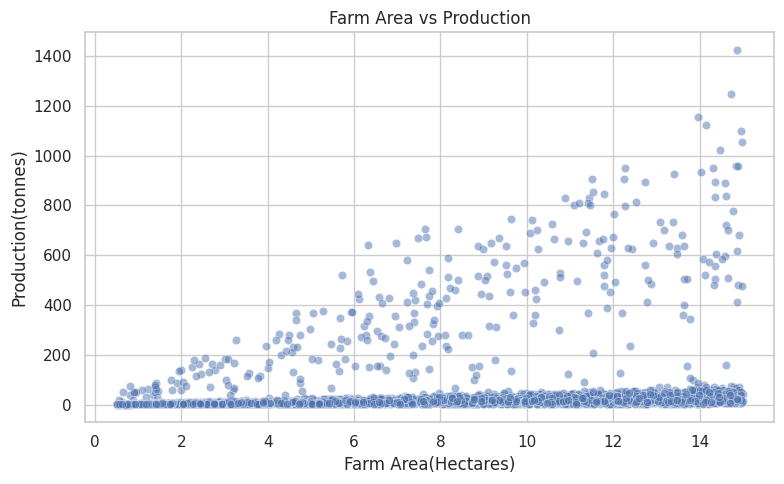

In [54]:
# Bivariate: Farm area vs Production

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("Farm Area vs Production")
plt.xlabel("Farm Area(Hectares)")
plt.ylabel("Production(tonnes)")
plt.tight_layout()
plt.show()

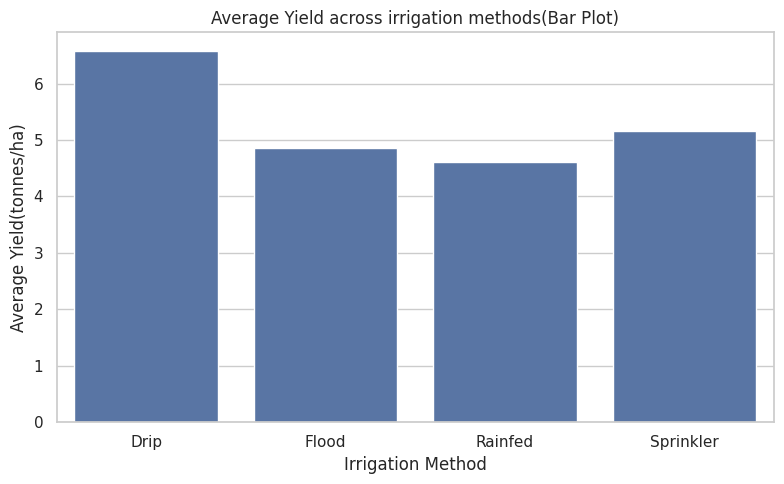

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average Yield across irrigation methods(Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

**11. Multivariate Analysis**





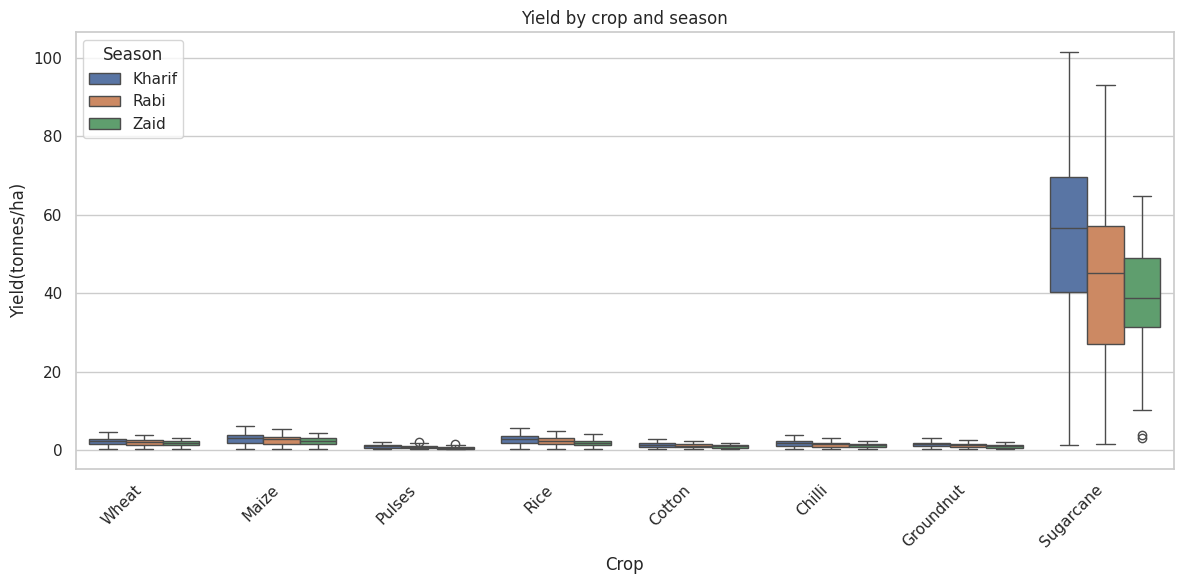

In [57]:
# Multivariate: Season, crop & yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Crop",y="Yield_Tonnes_Ha",hue="Season")
plt.xticks(rotation=45,ha="right")
plt.title("Yield by crop and season")
plt.xlabel("Crop")
plt.ylabel("Yield(tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

Multivariate: Pair Plot of Key Environmental and performance Metrics by Season

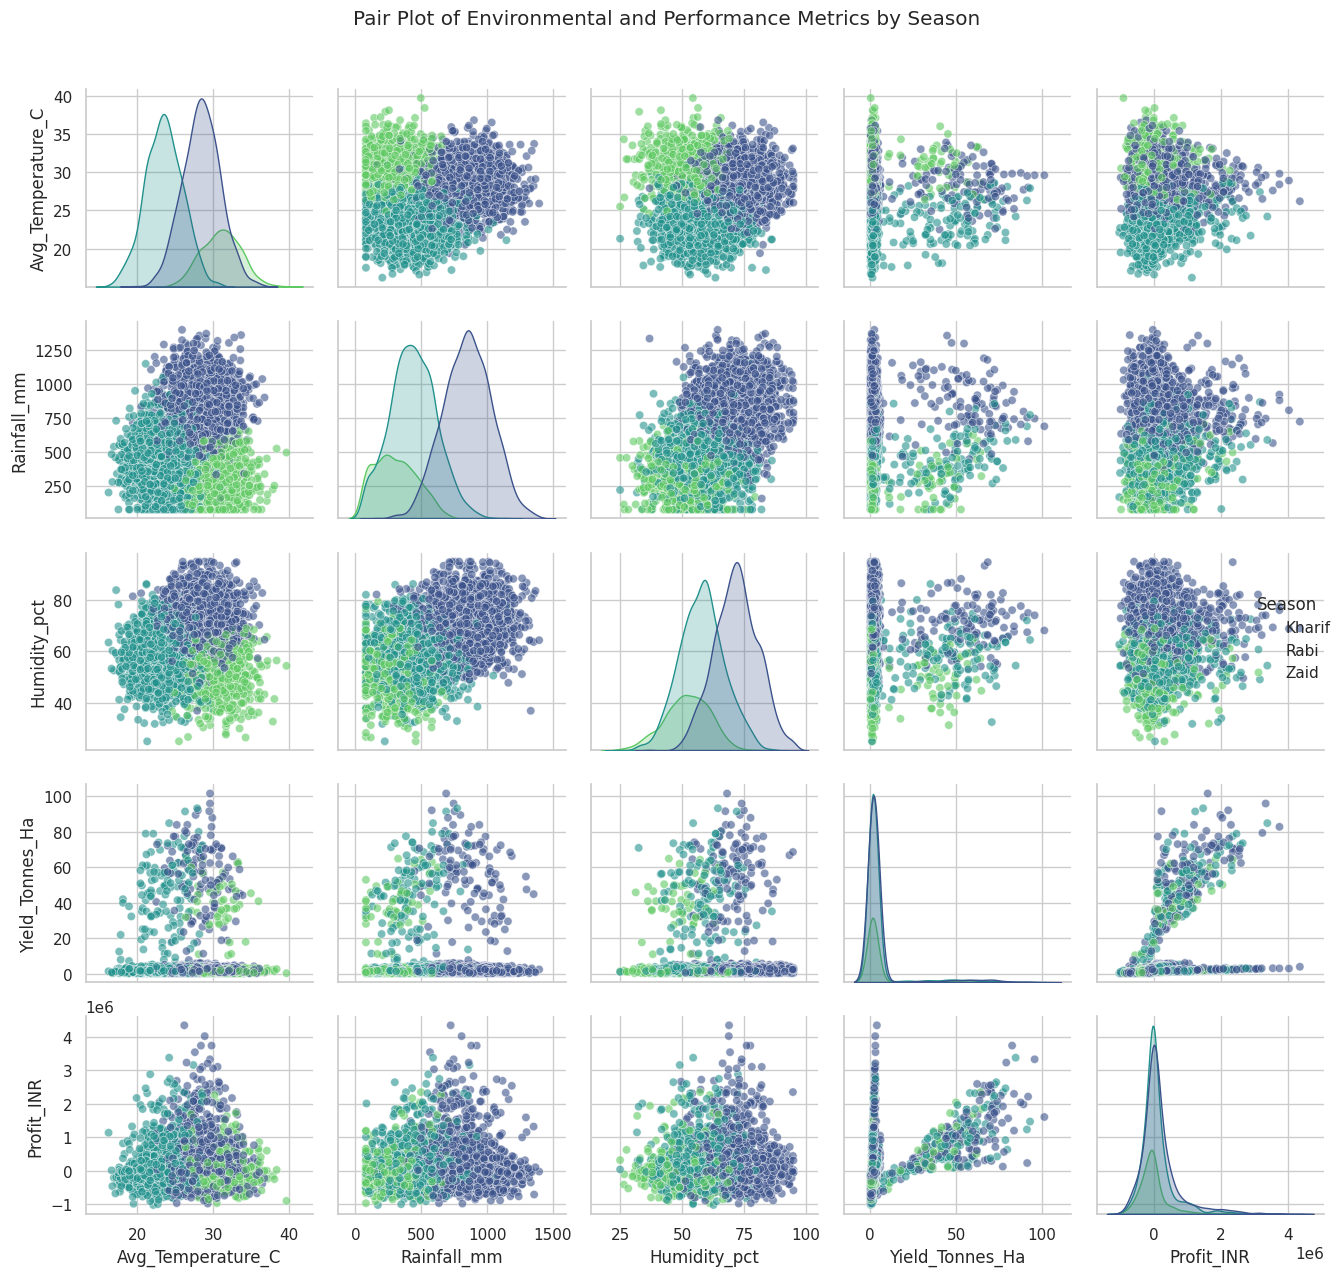

In [65]:
selected_columns=['Avg_Temperature_C','Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_columns],hue='Season',palette='viridis',plot_kws={'alpha':0.6})
plt.suptitle("Pair Plot of Environmental and Performance Metrics by Season",y=1.02)
plt.tight_layout()
plt.show()

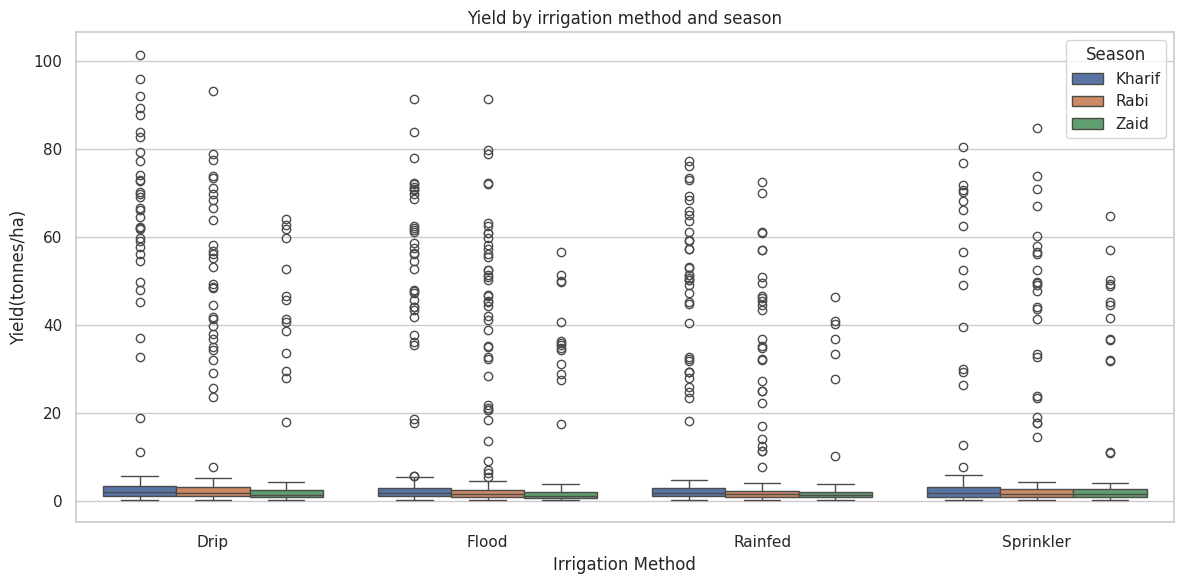

In [66]:
# Multivariate: Season, irrigation and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by irrigation method and season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield(tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

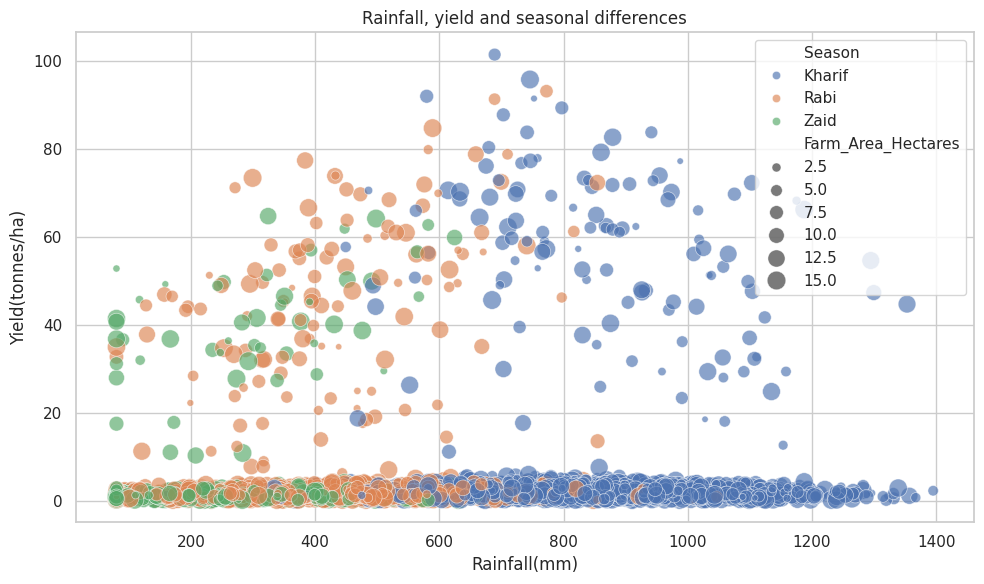

In [67]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",hue="Season",size="Farm_Area_Hectares",sizes=(20,180),alpha=0.65)
plt.title("Rainfall, yield and seasonal differences")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()

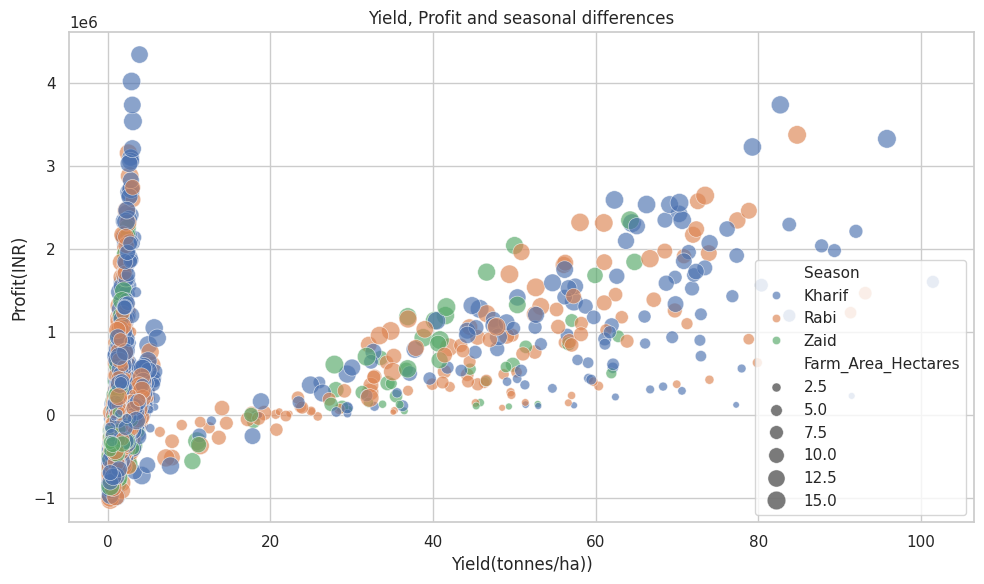

In [68]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Yield_Tonnes_Ha",y="Profit_INR",hue="Season",size="Farm_Area_Hectares",sizes=(20,180),alpha=0.65)
plt.title("Yield, Profit and seasonal differences")
plt.xlabel("Yield(tonnes/ha))")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

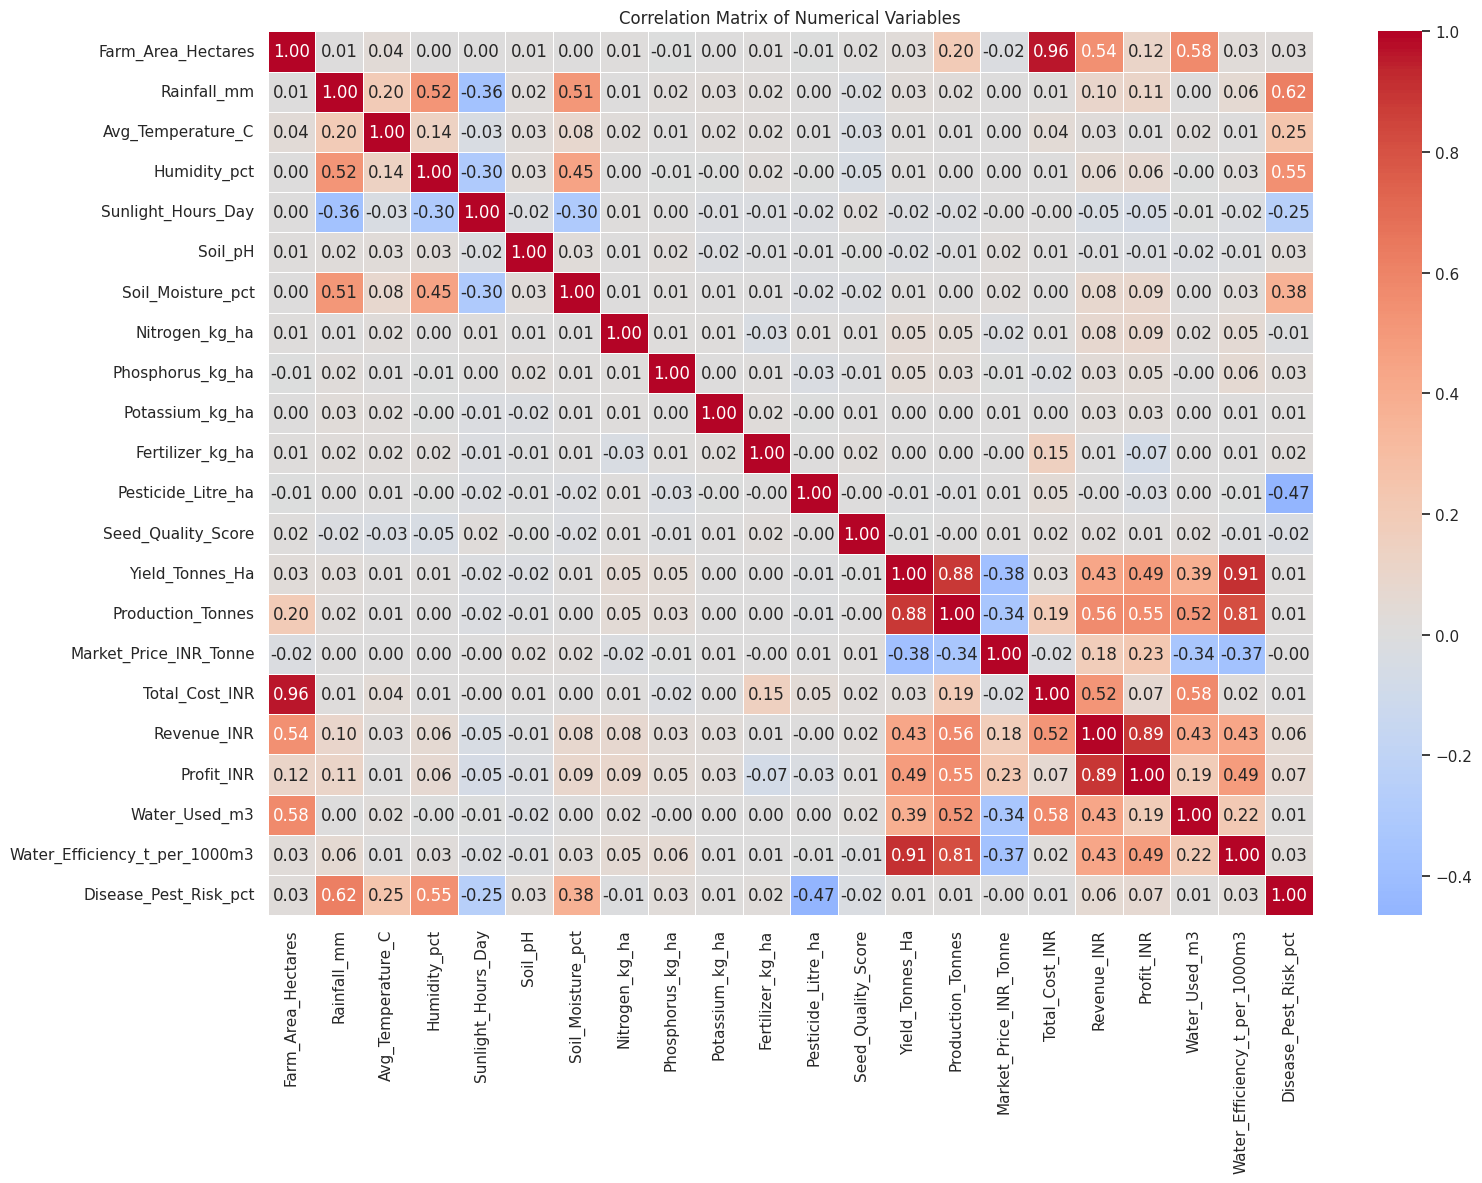

In [69]:
# Correlation heatmap for numerical variables

plt.figure(figsize=(16,12))
corr=df[numeric_columns].corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidth=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**12. Seasonal Comparison**

In [70]:
# General Seasonal Summary

season_metrics=df.groupby("Season").agg(
    Records=("Farm_ID","count"),
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Total_Production=("Production_Tonnes","sum"),
    Average_Profit=("Profit_INR","mean"),
    Total_Profit=("Profit_INR","sum"),
    Average_Water_Usage=("Water_Used_m3","mean")
).round(2)
season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Usage
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [71]:
# Compare crop performance within each season

crop_season_summary=(
    df.groupby(["Crop","Season"]).agg(
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Average_Profit=("Profit_INR","mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
    ).round(2).sort_values(["Season","Average_Yield"],ascending=[True,False])
)
crop_season_summary

,,Average_Yield,Average_Profit,Average_Water_Efficiency
Crop,Season,,,
Sugarcane,Kharif,53.46,"1,000,790.81",36.00
Maize,Kharif,2.97,"-39,332.67",6.05
Rice,Kharif,2.70,"-64,903.40",2.17
Wheat,Kharif,2.25,"-105,871.87",4.76
Chilli,Kharif,1.73,"954,380.42",3.26
Groundnut,Kharif,1.48,"108,265.44",3.58
Cotton,Kharif,1.37,"216,999.55",2.13
Pulses,Kharif,1.04,"43,338.90",3.35
Sugarcane,Rabi,43.29,"731,612.86",27.92


**13. Additional**

**Regional Differences**

Regional differences are relevant because the project is studying agricultural performance across different seasons and geographical areas.

                Yield_Tonnes_Ha  Profit_INR
State                                      
Andhra Pradesh             4.63   73,453.53
Gujarat                    5.66  117,568.24
Karnataka                  5.69  119,422.34
Madhya Pradesh             4.99   86,840.76
Maharashtra                5.02  135,428.86
Punjab                     6.12  136,025.64
Tamil Nadu                 4.88  117,744.75
Telangana                  5.04  108,829.62


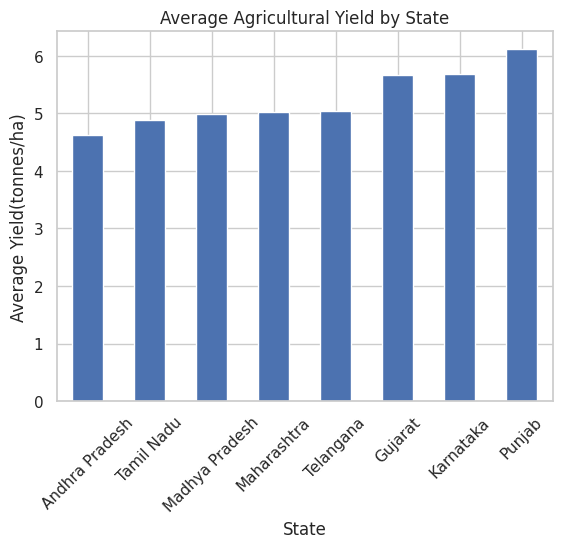

In [73]:
# Average Agricultural Yield by State
regional=df.groupby('State')[[
    'Yield_Tonnes_Ha',
    'Profit_INR'
]].mean().round(2)
print(regional)

regional['Yield_Tonnes_Ha'].sort_values().plot(kind='bar')
plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield(tonnes/ha)")
plt.xticks(rotation=45)
plt.show()

**Environmental Conditions**

Environmental conditions are relevant because they vary across seasons and can be associated with differences in agricultural performance.By analyzing rainfall,temperature,humidity,sunlight and soil moisture across the seasons, we can identify seasonal environmental patterns and examine their relationship with crop yield and other agricultural outcomes.

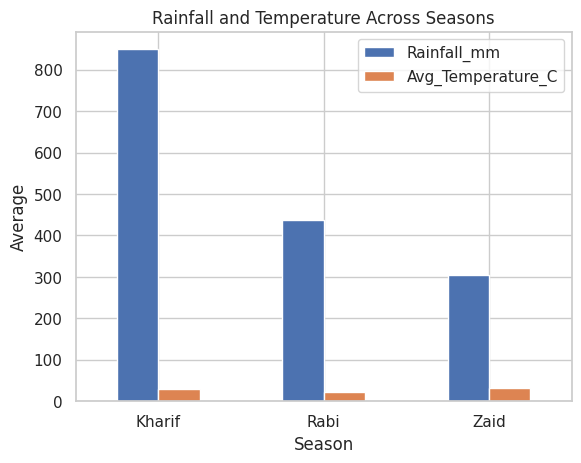

In [79]:
# Rainfall and Temperature across the Season

df.groupby('Season')[[
    'Rainfall_mm',
    'Avg_Temperature_C',
]].mean().round(2).plot(kind='bar')

plt.title("Rainfall and Temperature Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average")
plt.xticks(rotation=0)
plt.show()


**Economic Performance**

It helps to evaluate how agricultural outcomes differ financially across seasons.

        Total_Cost_INR  Revenue_INR  Profit_INR
Season                                         
Kharif      531,804.41   710,719.06  178,914.65
Rabi        513,836.58   601,526.05   87,689.47
Zaid        543,976.73   519,171.90  -24,804.82


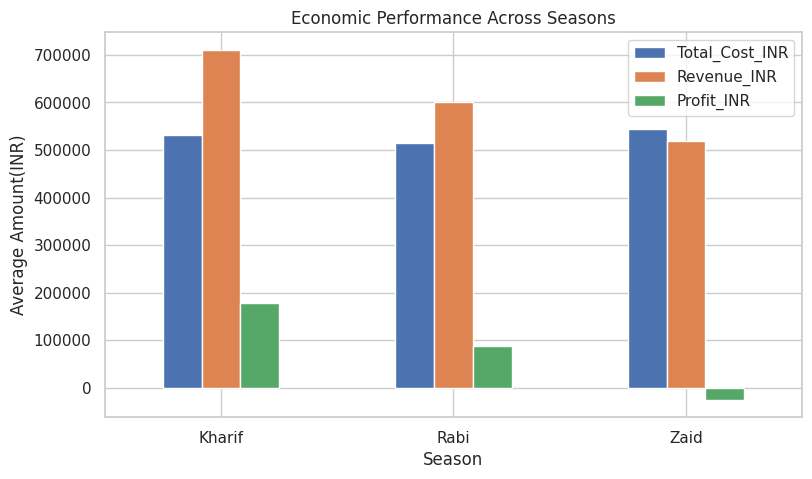

In [80]:
# Economic Performance Across Seasons
economic=df.groupby('Season')[[
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]].mean().round(2)
print(economic)

economic.plot(kind='bar',figsize=(9,5))
plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount(INR)")
plt.xticks(rotation=0)
plt.show()

**14. Key Insights**

**1. Punjab Outperforms in Agricultural Productivity**

**Obsevation**: Punjab records the highest yield per hectare among all analyzed states.

**Evidence**: The dataframe shows Punjab leads with a yield of 6.12 tonnes/ha and a high profit of rupees 136,025.64.as_integer_ratio

**Interpretation**: Optimized farming practices, superior irrigation, or favorable soil conditions give punjab a clear operational edge.

**Limitation**: The current metrics do not account for total acreage cultivated or regional cost of production.

**2. Kharif Season Dominates Total Precipitation**

**Observation:** Monsoon-driven precipitation peaks sharply during the Kharif season compared to all other cropping periods.

**Evidence:** Average rainfall during Kharif reaches over 800 mm, almost doubling the Rabi season levels.

**Interpretation:** Agriculture during this season relies heavily on heavy precipitation for water-intensive cropping (e.g., rice/paddy).

**Limitation:** Extreme precipitation variance or localized flooding risks are compressed into a single average value.

**3. Kharif Season Generates Peak Profitability**

**Observation:** Kharif delivers the highest absolute profit and revenue among all three seasons.

**Evidence:** The dataframe records Kharif revenue at ₹710,719.86 with a profit of ₹178,914.65, significantly outperforming Rabi and Zaid.

**Interpretation:** High seasonal rainfall and favorable growing conditions enable farmers to harvest higher-value or higher-volume crops during Kharif.

**Limitation:** The dataset does not detail individual crop profit margins within the Kharif cycle.

**4. Strong Positive Correlation Between Crop Yield and Profit**

**Observation:** As crop yield per hectare increases, profit per farming operation rises proportionally.

**Evidence:** Data points along the rightward diagonal cluster show profit scaling upward from near 0 up to over $3 \times 10^6$ INR as yield extends from ~20 to nearly 100 tonnes/ha.

**Interpretation:** Productivity per unit area is a primary driver of financial performance across farm holdings.

**Limitation:** The plot does not separate fixed overhead costs from variable market prices per crop type.

**5. Drip Irrigation Achieves Superior Crop Yield**

**Observation:** Drip irrigation delivers significantly higher productivity per hectare than all other water distribution methods.

**Evidence:** Drip irrigation yields over 6 tonnes/ha, outperforming the next closest method by more than 1 tonne/ha.

**Interpretation:** Precision water and nutrient delivery directly to crop roots maximizes plant growth while minimizing environmental losses.

**Limitation:** The chart does not show initial capital expenditure or installation costs for drip infrastructure.

**6. Positive Overall Relationship Between Farm Area and Production Output**

**Observation:** Maximum production output scales upward as farm area increases.

**Evidence:** The upper boundary of production points trends upward from ~200 tonnes for small holdings (<3 hectares) to over 1,400 tonnes for large holdings (14+ hectares).

**Interpretation:** Larger contiguous farm acreage enables higher overall yield capacity due to economies of scale and mechanical efficiencies.

**Limitation:** Farm area alone does not guarantee high output, as evidenced by large holdings that still generate minimal production.

**7. Consistent Core Water Demand Across All Seasons**

**Observation:** Interquartile ranges (IQRs) for overall water usage remain nearly identical regardless of the season.

**Evidence:** The blue box plots for Kharif, Rabi, and Zaid all span from roughly 2,500 $\text{m}^3$ to 8,000 $\text{m}^3$, with median lines consistently hovering around 4,500 $\text{m}^3$ to 5,000 $\text{m}^3$.

**Interpretation:** Baseline farm water requirements are fixed primarily by soil acreage and operational scale rather than seasonal atmospheric shifts.

**Limitation:** The plot tracks total water volume ($m^3$) used per farm, omitting distinction between natural rainfall intake and applied irrigation.

**8. Kharif Holds Plurality Share of Seasonal Records**

**Observation:** The Kharif season accounts for the single largest proportion of entries in the dataset.

**Evidence:** The pie chart demonstrates that Kharif occupies the largest slice, representing 44.5% (calculated as $100\% - 40.7\% - 14.8\%$) of total recorded instances.

**Interpretation:** Data collection reflects the primary reliance on monsoon-driven agriculture across the surveyed regions.

**Limitation:** A higher record count may reflect sampling bias rather than actual physical farm acreage.

**15. Recommendations**

**1. Transition Low-Yield Operations to Drip Irrigation**

**Recommendation:** Agriculture extension programs should prioritize funding and technical support for transitioning farms from flood and rainfed systems to drip irrigation.

**Data Connection:** Drip irrigation yields over 6 tonnes/ha, outperforming flood (~4.8 tonnes/ha) and rainfed (~4.5 tonnes/ha) systems by 25–35%.

**Limitation:** The dataset does not detail initial capital costs, equipment installation expenses, or power grid requirements needed for micro-irrigation deployment.

**2. Focus Capital and Commercial Efforts on the Kharif Cropping Cycle**

**Recommendation:** Financial institutions and farm managers should allocate the majority of seasonal credit and crop inputs toward Kharif season production.

**Data Connection:** Kharif produces the highest average top-line revenue (₹710,719.86) and net profit (₹178,914.65), achieving a profit-to-cost ratio of ~33.6% compared to Rabi (~17.1%) and Zaid (~4.5%).

**Limitation:** Soil rest requirements, crop rotation constraints, and seasonal land availability prevent continuous year-round cultivation exclusively in Kharif.

**3. Restructure Zaid Season Operations to Mitigate High Cost Overhead**

**Recommendation:** Farmers planting during the summer (Zaid) season should shift to low-water-demand, high-margin niche crops or utilize fallow practices to avoid operating losses.

**Data Connection:** Zaid incurs the highest seasonal production cost (₹543,976.73) while generating the lowest average revenue (₹519,171.90) and profit (₹24,804.82). Furthermore, Zaid's water usage floor is elevated due to peak temperatures (30°C–35°C) combined with lowest rainfall (~300 mm).

**Limitation:** Market demand for specific heat-tolerant summer crops or local government price supports are not tracked in the dataset.

**4. Implement Targeted Productivity Interventions in Low-Performing States**

**Recommendation:** State-level agricultural agencies in Andhra Pradesh and Madhya Pradesh should audit local farming practices to adopt high-yield techniques used in Punjab and Gujarat.

**Data Connection:** Punjab achieves a high yield of 6.12 tonnes/ha and profit of ₹136,025.64, whereas Andhra Pradesh records the lowest yield (4.63 tonnes/ha) and profit (₹73,453.53). Madhya Pradesh also underperforms in monetization (₹86,840.76 profit at 4.99 tonnes/ha) compared to Telangana (₹108,829.62 profit at 5.04 tonnes/ha).

**Limitation:** The data aggregates state totals without accounting for district-level soil profiles, specific crop varieties grown, or regional supply chain bottlenecks.

**5. Prioritize Scale Optimization for Smallholders via Cooperative Farming**

**Recommendation:** Small-scale landholders (<4 hectares) should consider pooling land resources into farm cooperatives to breach production volume ceilings.

**Data Connection:** Total production for farms under 4 hectares is capped below 200–300 tonnes, whereas farms larger than 10 hectares reach volumes exceeding 800 to 1,400 tonnes and secure higher overall profits ($>2 \times 10^6$ INR).

**Limitation:** Land ownership laws, cooperative management overhead, and land fragmentation dynamics are outside the scope of the analyzed dataset.

**16. Conclusion**





The Seasonal Agriculture Performance Analysis provides a clear understanding of how agricultural performance varies across different seasons and regions. The analysis shows that Kharif generally has the highest average yield, production, revenue, and profit, while Zaid shows comparatively lower agricultural and economic performance.

The study also identifies clear seasonal variations in rainfall, temperature, humidity, sunlight, and soil moisture. Resource usage also differs across seasons, with Zaid showing higher average water usage but lower water efficiency. Disease and pest risk is highest during Kharif in the available data.

Regional and crop-wise analysis shows that seasonal patterns are not identical everywhere. Some states and crops perform differently depending on the season. These variations demonstrate the importance of considering season, region, crop, environmental conditions, resource usage, and economic outcomes together when evaluating agricultural performance.

Overall, the analysis provides useful data-driven insights into seasonal differences in agriculture. The findings can support better seasonal agricultural planning by helping identify stronger-performing seasons, regions, and areas where resource usage and economic performance require greater attention. However, the conclusions are limited to the patterns observed in the available dataset and should not be interpreted as proof of direct cause-and-effect relationships.